In [1]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('train.csv', usecols= ['Age', 'Fare', 'Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [8]:
X_train

,Age,Fare
140,NaN,15.2458
439,31.0,10.5000
817,31.0,37.0042
378,20.0,4.0125
491,21.0,7.2500
...,...,...
835,39.0,83.1583
192,19.0,7.8542
629,NaN,7.7333
559,36.0,17.4000


In [9]:
X_train['Age_imputed'] = X_train['Age'] 
X_test['Age_imputed'] = X_test['Age']

In [10]:
X_test.tail()

,Age,Fare,Age_imputed
780,13.0,7.2292,13.0
837,NaN,8.0500,NaN
215,31.0,113.2750,31.0
833,23.0,7.8542,23.0
372,19.0,8.0500,19.0


In [11]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\Mani\AppData\Local\Temp\ipykernel_16828\3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C:

In [12]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([71.  , 44.  , 24.  , 42.  , 47.  , 33.  , 24.  , 28.  ,  1.  ,
       28.  , 20.5 ,  4.  , 39.  , 40.5 , 34.  , 21.  , 35.  , 24.  ,
       28.  , 22.  , 29.  , 21.  , 18.  , 32.  , 31.  , 22.  , 24.  ,
       22.  ,  4.  , 28.  , 27.  , 26.  ,  0.83, 30.  , 27.  , 37.  ,
       34.  , 41.  , 37.  , 27.  , 18.  , 24.  ,  6.  , 27.  , 33.  ,
       28.  , 51.  , 37.  , 22.  , 38.  , 28.  , 16.  , 21.  , 21.  ,
       35.  ,  2.  , 47.  , 38.  , 18.  , 20.  , 50.  , 18.  , 18.  ,
       30.  , 21.  , 22.  , 24.  , 41.  , 23.  , 24.  , 70.  ,  2.  ,
       24.  , 30.  , 18.  ,  9.  , 18.  , 36.  , 57.  , 36.  , 30.  ,
       25.  ,  4.  , 44.  , 19.  , 26.  , 36.  , 29.  , 30.  , 24.  ,
       45.  , 29.  , 28.  , 15.  , 34.  ,  4.  , 24.  , 19.  , 28.  ,
       28.  , 59.  , 16.  , 31.  , 15.  , 34.  , 12.  , 24.  , 55.  ,
       38.  , 19.  , 36.  , 35.  , 26.  , 48.  , 36.  , 23.  ,  8.  ,
       36.  , 41.  ,  2.  , 45.  , 27.  , 18.  , 40.  , 29.  , 34.  ,
       33.  , 14.  ,

In [13]:
X_train['Age'].isnull().sum()

np.int64(141)

In [14]:
X_train

,Age,Fare,Age_imputed
140,NaN,15.2458,2.0
439,31.0,10.5000,31.0
817,31.0,37.0042,31.0
378,20.0,4.0125,20.0
491,21.0,7.2500,21.0
...,...,...,...
835,39.0,83.1583,39.0
192,19.0,7.8542,19.0
629,NaN,7.7333,43.0
559,36.0,17.4000,36.0


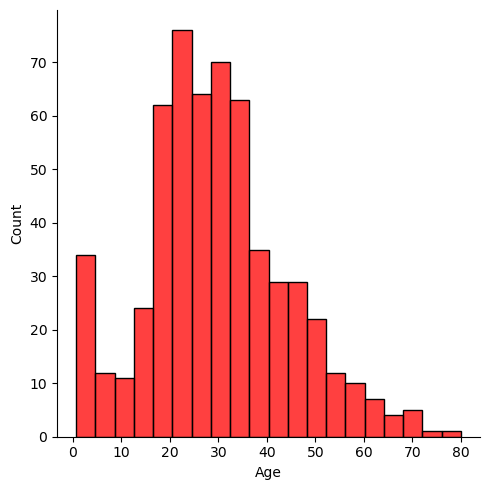

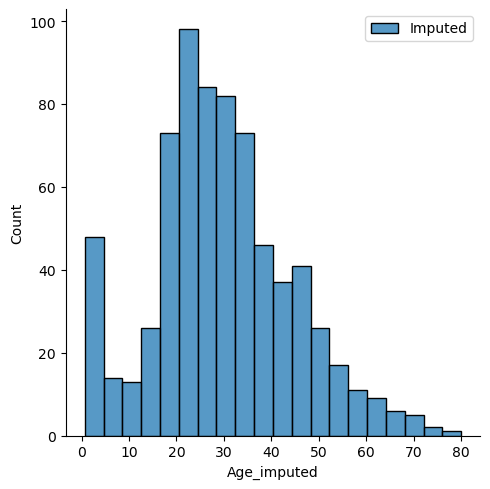

In [21]:
sns.displot(X_train['Age'], label='Original', color='red' )
sns.displot(X_train['Age_imputed'], label='Imputed')
plt.legend()    
plt.show()

In [22]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  213.7165085187578
Variance after random imputation:  218.95967329445799


In [23]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2513.549265,79.072379,54.891730
Age,79.072379,213.716509,213.716509
Age_imputed,54.891730,213.716509,218.959673


<Axes: >

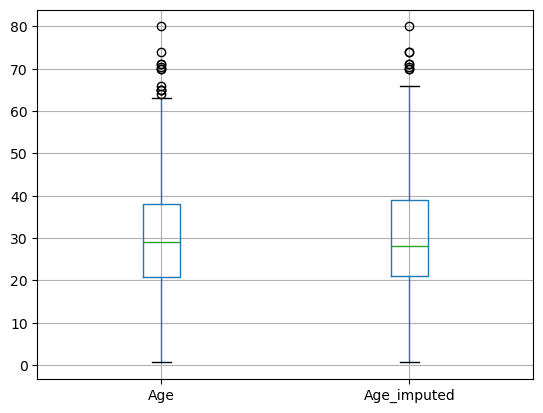

In [24]:
X_train[['Age', 'Age_imputed']].boxplot()

In [31]:
import math
observation = X_train.iloc[1]
fare = observation['Fare']
if not math.isnan(fare):
    rs = int(fare)
else:
    rs = 0

sampled_value = X_train['Age'].dropna().sample(1, random_state=rs)

In [32]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [34]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [35]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [36]:
X = data
y = data['SalePrice']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [38]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [40]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1069,NaN,TA,135000,TA,NaN
947,Gd,TA,270000,TA,Gd
137,NaN,TA,171000,TA,NaN
917,NaN,TA,135000,TA,NaN
105,Gd,TA,250000,TA,Gd


In [41]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\Mani\AppData\Local\Temp\ipykernel_16828\856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'

In [42]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [43]:
temp

,original,imputed
TA,0.950450,0.951199
Fa,0.036036,0.035103
Gd,0.009009,0.008562
Po,0.002703,0.002568
Ex,0.001802,0.002568


In [44]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.478120,0.627385
TA,0.416532,0.543210
Fa,0.047002,0.061728
Ex,0.030794,0.042649
Po,0.027553,0.035915


C:\Users\Mani\AppData\Local\Temp\ipykernel_16828\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Mani\AppData\Local\Temp\ipykernel_16828\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6

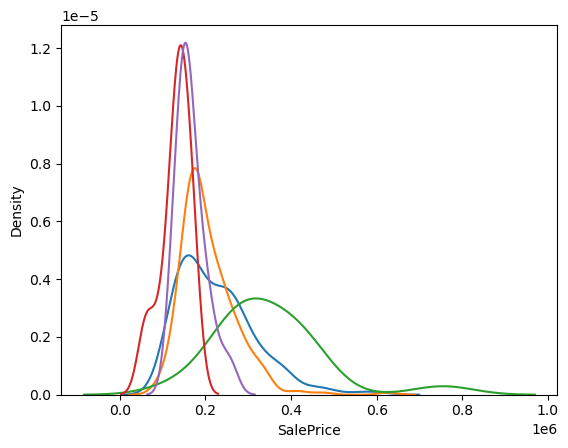

In [45]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\Mani\AppData\Local\Temp\ipykernel_16828\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Mani\AppData\Local\Temp\ipykernel_16828\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974

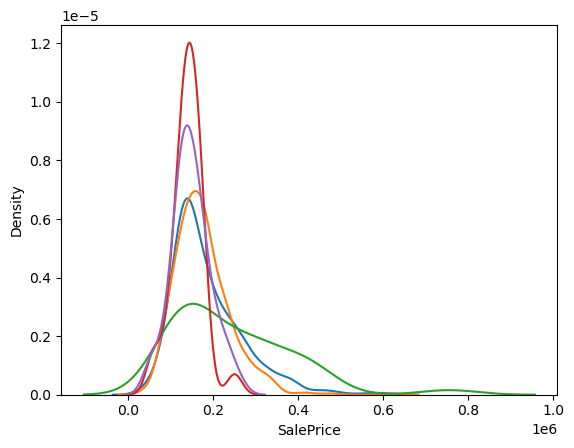

In [46]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()